In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.io as io
import json
import pandas as pd
import numpy as np
import os
import ast
from PIL import Image
import re
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, Sampler
import random
from typing import List
from torch.optim.lr_scheduler import _LRScheduler
import math
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
from vit import Encoder

/Users/saptarshimallikthakur/Pictures/VLM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
COCO_KEYPOINTS = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
                  'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
                  'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
                  'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
                  ]

device = 'mps'

In [ ]:
def generate_target(joints, joints_vis, output_size=(32, 32), imgsize=224, sigma=2):
    """
    Generates Gaussian Heatmaps.
    joints: [17, 2] coordinates (x, y) in the INPUT IMAGE scale (e.g., 224x224)
    joints_vis: [17] visibility flags (0=hidden, 1=visible, 2=visible+labeled)
    """
    num_joints = joints.shape[0]
    target = torch.zeros((num_joints, output_size[0], output_size[1]), dtype=torch.float32)
    target_weight = torch.zeros((num_joints, 1), dtype=torch.float32)
    
    tmp_size = sigma * 1

    for joint_id in range(num_joints):
        # 1. Check visibility. If 0, skip generation, weight remains 0.
        v = joints_vis[joint_id]
        if v == 0:
            continue
            
        target_weight[joint_id] = 1.0

        # 2. Scale coordinate to Heatmap size 
        # Assuming input 224 -> output 56, stride is 4
        feat_stride = imgsize // output_size[0]
        mu_x = int(joints[joint_id][0] / feat_stride + 0.5)
        mu_y = int(joints[joint_id][1] / feat_stride + 0.5)
        
        # 3. Check if joint is inside the heatmap bounds
        ul = [int(mu_x - tmp_size), int(mu_y - tmp_size)]
        br = [int(mu_x + tmp_size + 1), int(mu_y + tmp_size + 1)]

        if ul[0] >= output_size[1] or ul[1] >= output_size[0] or br[0] < 0 or br[1] < 0:
            # Joint outside heatmap
            target_weight[joint_id] = 0
            continue

        # 4. Generate Gaussian
        size = 2 * tmp_size + 1
        x = torch.arange(0, size, dtype=torch.float32)
        y = torch.arange(0, size, dtype=torch.float32)

        yy, xx = torch.meshgrid(y, x, indexing="ij")

        xx = xx - tmp_size
        yy = yy - tmp_size

        g = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))


        # 5. Handle Boundary Clipping (if Gaussian goes off edge)
        g_x = max(0, -ul[0]), min(br[0], output_size[1]) - ul[0]
        g_y = max(0, -ul[1]), min(br[1], output_size[0]) - ul[1]
        img_x = max(0, ul[0]), min(br[0], output_size[1])
        img_y = max(0, ul[1]), min(br[1], output_size[0])

        target[joint_id][img_y[0]:img_y[1], img_x[0]:img_x[1]] = g[g_y[0]:g_y[1], g_x[0]:g_x[1]]

    return target, target_weight

target shape: torch.Size([3, 32, 32])
target_weight: [1.0, 1.0, 1.0]


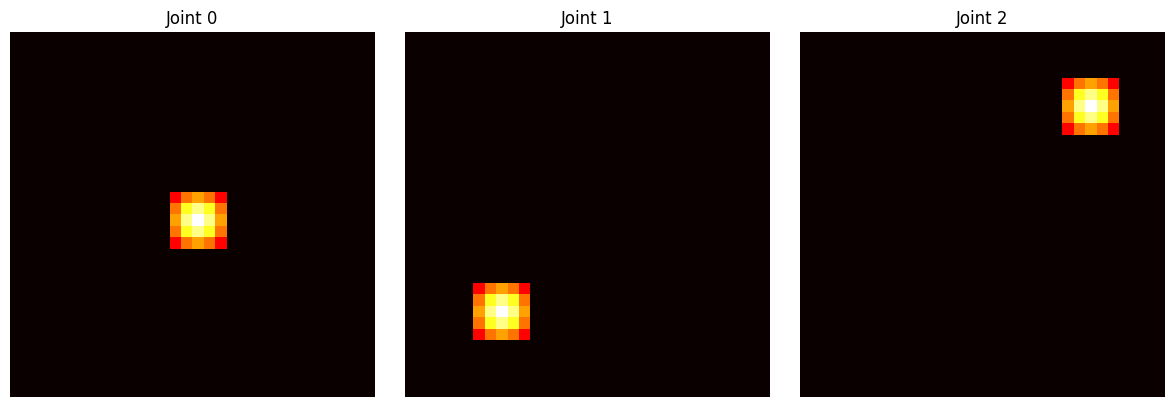

In [ ]:
# -------------------------------
# Dummy input (example joints)
# -------------------------------
# 3 joints for simplicity
joints = torch.tensor([
    [128, 128],   # center of image
    [56, 192],    # bottom-left-ish
    [200, 50]     # top-right-ish
], dtype=torch.float32)

joints_vis = torch.tensor([1, 1, 1], dtype=torch.int56)

# -------------------------------
# Run function
# -------------------------------
target, target_weight = generate_target(
    joints,
    joints_vis,
    output_size=(32, 32),
    imgsize=224,
    sigma=2
)

print("target shape:", target.shape)
print("target_weight:", target_weight.squeeze().tolist())

# -------------------------------
# Visualize heatmaps
# -------------------------------
fig, axes = plt.subplots(1, target.shape[0], figsize=(12, 4))

for i in range(target.shape[0]):
    ax = axes[i]
    hm = target[i].numpy()
    ax.imshow(hm, cmap="hot")
    ax.set_title(f"Joint {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def square_crop_with_margin(img, bbox, margin=0):
    """
    Crops the image around the bbox and pads to make it square.
    Returns: cropped_img, (x_offset, y_offset)
    """
    x, y, w, h = map(int, bbox)
    H, W = img.shape[:2]

    # Add margin
    x -= margin
    y -= margin
    w += 2*margin
    h += 2*margin

    # Make square
    center_x = x + w / 2
    center_y = y + h / 2
    side = max(w, h)
    
    # Calculate new top-left
    new_x = int(center_x - side / 2)
    new_y = int(center_y - side / 2)
    side = int(side)

    # Handle padding if crop goes out of bounds
    pad_l = max(0, -new_x)
    pad_t = max(0, -new_y)
    pad_r = max(0, (new_x + side) - W)
    pad_b = max(0, (new_y + side) - H)

    # Crop valid area
    crop_x1 = max(0, new_x)
    crop_y1 = max(0, new_y)
    crop_x2 = min(W, new_x + side)
    crop_y2 = min(H, new_y + side)

    cropped = img[crop_y1:crop_y2, crop_x1:crop_x2]

    # Pad with zeros (black) to maintain square shape
    if pad_l > 0 or pad_t > 0 or pad_r > 0 or pad_b > 0:
        cropped = cv2.copyMakeBorder(cropped, pad_t, pad_b, pad_l, pad_r, cv2.BORDER_CONSTANT, value=(0,0,0))

    return cropped, new_x, new_y, side

class COCOKeypointDataset(Dataset):
    def __init__(self, coco_json, img_dir, input_size=(224, 224), heatmap_size=(56, 56), max_samples=None):
        """
        Standard Pose Estimation Dataset.
        Output: Image [3, 224, 224], Target [17, 56, 56], TargetWeight [17, 1]
        """
        with open(coco_json, "r") as f:
            self.data = json.load(f)
        
        self.img_dir = img_dir
        self.input_size = input_size   # e.g., (224, 224)
        self.heatmap_size = heatmap_size # e.g., (56, 56)

        # Image normalization (Standard ImageNet mean/std)
        self.transform = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        self.samples = []
        
        # Create a lookup for image filenames to avoid O(N) search
        self.img_id_to_file = {img['id']: img['file_name'] for img in self.data['images']}

        print("🔍 Building COCO keypoint dataset...")
        for ann in tqdm(self.data["annotations"], desc="Processing annotations"):
            if ann["category_id"] != 1 or ann["num_keypoints"] == 0:
                continue
            
            # We treat every annotation (person) as a training sample
            img_filename = self.img_id_to_file.get(ann["image_id"])
            if not img_filename: continue

            img_path = os.path.join(self.img_dir, img_filename)
            
            # Store everything needed to process on the fly
            self.samples.append({
                "img_path": img_path,
                "bbox": ann["bbox"],
                "keypoints": ann["keypoints"] # List of [x, y, v, x, y, v...]
            })
            
            if max_samples and len(self.samples) >= max_samples:
                break
        
        print(f"✅ Total valid samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        
        # 1. Load Image
        img = cv2.imread(s["img_path"])
        if img is None:
            raise ValueError(f"Image not found: {s['img_path']}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Parse Raw Keypoints
        raw_kps = np.array(s["keypoints"]).reshape(-1, 3) # [17, 3] -> (x, y, v)
        joints = raw_kps[:, :2].astype(np.float32)
        joints_vis = raw_kps[:, 2].astype(np.float32)

        # 3. Crop Logic (Square crop around person)
        crop_img, offset_x, offset_y, crop_side = square_crop_with_margin(img, s["bbox"], margin=10)

        # 4. Transform Keypoints to Crop Coordinates
        # (x_new = x_old - top_left_crop_x)
        joints[:, 0] -= offset_x
        joints[:, 1] -= offset_y

        # 5. Resize to Model Input Size (e.g., 224x224)
        # We need the scale factor
        resize_ratio_x = self.input_size[1] / crop_side
        resize_ratio_y = self.input_size[0] / crop_side # Should be same since square

        img_final = cv2.resize(crop_img, (self.input_size[1], self.input_size[0]))
        
        # Apply same scale to joints
        joints[:, 0] *= resize_ratio_x
        joints[:, 1] *= resize_ratio_y

        # 6. Generate Heatmaps & Weights
        # joints are now in 224x224 space. generate_target will divide by 4.
        target_heatmaps, target_weights = generate_target(
            joints, 
            joints_vis, 
            self.heatmap_size
        )

        # 7. Apply Image Transforms (Norm, Tensor)
        img_tensor = self.transform(img_final)

        return {
            "image": img_tensor,            # [3, 224, 224]
            "target": target_heatmaps,      # [17, 56, 56]
            "target_weight": target_weights # [17, 1]
        }

In [6]:
# Define paths (Adjust to your local paths)
JSON_PATH = "/Users/saptarshimallikthakur/Pictures/detection daatset/COCO/annotations/person_keypoints_train2017.json"
IMG_DIR = "/Users/saptarshimallikthakur/Pictures/detection daatset/COCO/train2017"

dataset = COCOKeypointDataset(
    coco_json=JSON_PATH,
    img_dir=IMG_DIR,
    input_size=(224, 224),
    heatmap_size=(56, 56)
)

dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

🔍 Building COCO keypoint dataset...


Processing annotations: 100%|██████████| 262465/262465 [00:01<00:00, 227545.81it/s]

✅ Total valid samples: 149813


In [7]:
def unnormalize_image(img_tensor):
    """
    img_tensor: [3, H, W] (ImageNet normalized)
    returns: HWC image in [0,1]
    """
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = (img * std + mean).clip(0, 1)
    return img

def heatmaps_to_keypoints(target, target_weight, img_size):
    """
    target: [J, h, w]
    target_weight: [J, 1]
    img_size: (H, W)
    returns: list of (x, y) or None
    """
    J, h, w = target.shape
    H, W = img_size

    keypoints = []

    for j in range(J):
        if target_weight[j] == 0:
            keypoints.append(None)
            continue

        hm = target[j]

        # argmax in heatmap
        idx = torch.argmax(hm)
        y_hm = idx // w
        x_hm = idx % w

        # scale to image space
        x_img = (x_hm.float() + 0.5) * (W / w)
        y_img = (y_hm.float() + 0.5) * (H / h)

        keypoints.append((x_img.item(), y_img.item()))

    return keypoints

def visualize_reprojection(sample):
    image = sample["image"]
    target = sample["target"]
    target_weight = sample["target_weight"]

    img = unnormalize_image(image)
    H, W = img.shape[:2]

    keypoints = heatmaps_to_keypoints(
        target,
        target_weight,
        img_size=(H, W)
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")

    for j, kp in enumerate(keypoints):
        if kp is None:
            continue

        x, y = kp
        plt.scatter(x, y, c="lime", s=30)
        plt.text(x - 5, y - 5, str(COCO_KEYPOINTS[j]), color="yellow", fontsize=6)

    plt.title("Reprojected Keypoints from Heatmaps")
    plt.show()

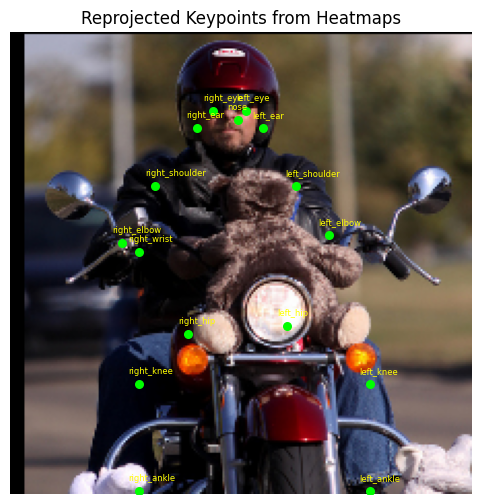

In [8]:
idx = 4
sample = dataset[idx]

visualize_reprojection(sample)

In [ ]:
EMB_DIM = 192
NUM_HEADS = EMB_DIM // 32
PATCH_SIZE = 8
DEPTH = 6

class PatchUnembedding(nn.Module):
    def __init__(self, patch_size, out_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.out_channels = out_channels

        self.proj = nn.Linear(embed_dim, out_channels * patch_size * patch_size)

    def forward(self, x):
        """
        x: (B, N, D)
        """
        B, N, D = x.shape

        H = W = int(N ** 0.5)
        assert H * W == N, f"N={N} is not a perfect square"

        P = self.patch_size
        C = self.out_channels

        x = self.proj(x)                
        x = x.view(B, H, W, C, P, P)
        x = x.permute(0, 3, 1, 4, 2, 5)   
        x = x.reshape(B, C, H * P, W * P)

        return x

class VitPose(nn.Module):
    def __init__(self, emb_dim=192):
        super().__init__()
        # Increased depth and MLP ratio for better capacity
        self.encoder = Encoder(patch_size=PATCH_SIZE, embed_dim=emb_dim, depth=DEPTH, num_heads=NUM_HEADS, mlp_ratio=3)
        self.unpatch = PatchUnembedding(2, 17, emb_dim)

    def forward(self, img):
        x = self.encoder(img) # (B, N, D)
        x = self.unpatch(x) # (B,C,H,W)
        return x
    

model = VitPose(EMB_DIM)
model.to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}")
print(f"Frozen params    : {total - trainable:,}")

Total params     : 2,989,892
Trainable params : 2,989,892
Frozen params    : 0


In [10]:
class JointsMSELoss(nn.Module):
    def __init__(self, use_target_weight=True):
        super(JointsMSELoss, self).__init__()
        self.criterion = nn.MSELoss(reduction='none') 
        self.use_target_weight = use_target_weight

    def forward(self, output, target, target_weights):
        batch_size = output.size(0)
        num_joints = output.size(1)
        
        heatmaps_pred = output.reshape((batch_size, num_joints, -1))
        heatmaps_gt = target.reshape((batch_size, num_joints, -1))
        
        loss = 0.5 * self.criterion(heatmaps_pred, heatmaps_gt)
        
        if self.use_target_weight:
            loss = loss * target_weights
        
        # CHANGED: Sum over pixels instead of Mean, as many background pixels and those are zeros !
        loss = loss.sum(dim=2) 
        
        # Normalize by batch size and valid joints only
        loss = loss.sum() / target_weights.sum().clamp(min=1)
        return loss

class CustomLRScheduler(_LRScheduler):
    def __init__(self, optimizer, total_steps, warmup_steps_ratio, min_lr, max_lr, last_epoch=-1):
        self.total_steps = total_steps
        self.warmup_steps = int(total_steps * warmup_steps_ratio)
        self.min_lr = min_lr
        self.max_lr = max_lr
        super(CustomLRScheduler, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        current_step = self.last_epoch
        if current_step < self.warmup_steps:
            lr = self.min_lr + (self.max_lr - self.min_lr) * (current_step / self.warmup_steps)
        else:
            progress = (current_step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            decay_factor = math.exp(-1.0 * progress)
            lr = self.min_lr + (self.max_lr - self.min_lr) * decay_factor
            lr = max(lr, self.min_lr)
        return [lr for _ in self.base_lrs]
    
EPOCHS = 5
TOTAL_STEPS = len(dataloader)*EPOCHS

LEARNING_RATE_MIN = 1e-5
LEARNING_RATE_MAX = 1e-3
WARMUP_RATIO = 0.1

# --- Optimizer ---
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE_MAX, betas=(0.9, 0.98), eps=1e-9)
loss_fn = JointsMSELoss().to(device)
scheduler = CustomLRScheduler(
    optimizer,TOTAL_STEPS,
    warmup_steps_ratio=WARMUP_RATIO,
    min_lr=LEARNING_RATE_MIN,
    max_lr=LEARNING_RATE_MAX
)

In [ ]:
model.train()

for epoch in range(EPOCHS):

    loss_train = 0.0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True, unit='batch')

    for batch in progress_bar:

        imgs          = batch['image'].to(device)
        target        = batch["target"].to(device)                  
        target_weight = batch["target_weight"].to(device)  

        pred = model(imgs)                          
        loss = loss_fn(pred, target, target_weight)

        loss_train += loss.item()

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix(loss=loss.item(), lr=f"{scheduler.get_last_lr()[0]:.6f}")

    loss_tensor = torch.tensor([loss_train], device=device)
    avg_loss = loss_tensor[0].item() / len(dataloader)

    print(f"Epoch {epoch+1} | Loss {avg_loss:.4f} | ")
    
    torch.save(model.state_dict(), 'model.pt')


Epoch 1/5: 100%|██████████| 4682/4682 [1:37:48<00:00,  1.25s/batch, loss=4.52, lr=0.000896]


Epoch 0 | Loss 7.4668 | 


Epoch 2/5: 100%|██████████| 4682/4682 [1:38:32<00:00,  1.26s/batch, loss=3.63, lr=0.000719]


Epoch 1 | Loss 4.0147 | 


Epoch 3/5: 100%|██████████| 4682/4682 [1:38:41<00:00,  1.26s/batch, loss=4.12, lr=0.000578]


Epoch 2 | Loss 3.5980 | 


Epoch 4/5: 100%|██████████| 4682/4682 [1:38:44<00:00,  1.27s/batch, loss=3.37, lr=0.000465]


Epoch 3 | Loss 3.3258 | 


Epoch 5/5: 100%|██████████| 4682/4682 [1:38:45<00:00,  1.27s/batch, loss=2.54, lr=0.000374]

Epoch 4 | Loss 3.1308 | 
